# Ejercicio 1 — Dataset Iris

El dataset `iris.csv` contiene información sobre 150 flores de iris de tres especies diferentes: *setosa*, *versicolor* y *virginica*. Para cada flor, se midieron cuatro características: longitud y ancho del sépalo (la parte que rodea y protege el capullo de la flor) y longitud y ancho del pétalo (la parte coloreada de la flor).

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='ticks')

data_iris = pd.read_csv('../Datasets/iris.csv')
data_iris.head()

,id,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


## Ítem 1 — Histograma del ancho de sépalo

> **Reproduzca el histograma mostrado en la figura para visualizar la distribución del ancho de sépalo (`sepal_width_cm`).**
>
> **Sugerencias:**
> - Configure previamente el *theme* de Seaborn utilizando `sns.set_theme(style='ticks')`.
> - El color de las barras debe ser **darkred** y deben tener borde negro.
> - El eje vertical debe expresarse en porcentaje.
> - Considere una partición en 12 intervalos de igual amplitud (0.2), cubriendo el rango desde 2.0 hasta 4.4. Puede lograrlo mediante el argumento `bins` y/o `binrange`.

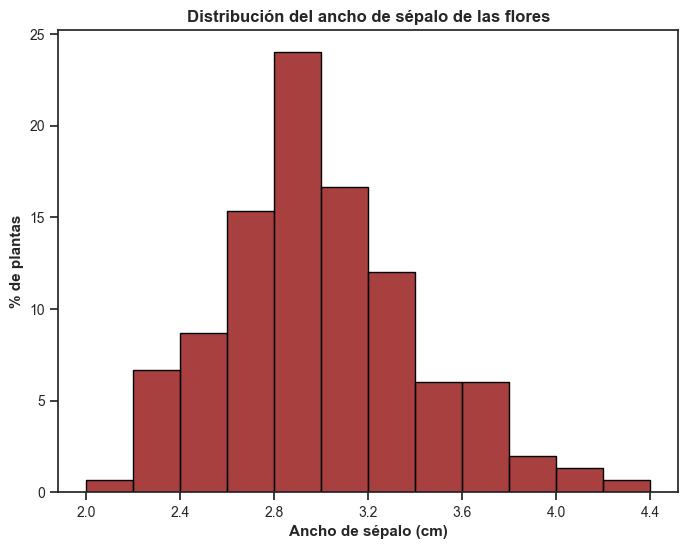

In [2]:
plt.figure(figsize=(8, 6))
sns.histplot(x='sepal_width_cm', fill=True, stat='percent', color='darkred',
             edgecolor='black', data=data_iris, bins=np.arange(2, 4.5, 0.2))
plt.xlabel('Ancho de sépalo (cm)', fontweight='bold', fontsize=11)
plt.title('Distribución del ancho de sépalo de las flores', fontweight='bold')
plt.xticks(np.arange(2, 4.5, 0.4), fontsize=10)
plt.yticks(fontsize=10)
plt.ylabel('% de plantas', fontweight='bold', fontsize=11)
plt.show()

## Ítem 2 — Boxplot múltiple: largo del pétalo por especie

> **Realice un boxplot múltiple que permita comparar la distribución del largo del pétalo de las flores entre las distintas especies. Comente brevemente lo observado. ¿Cuál de las especies presenta una mayor mediana del largo del pétalo?**

C:\Users\PC\AppData\Local\Temp\ipykernel_15832\3143020282.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species', y='petal_length_cm', data=data_iris, palette='muted')


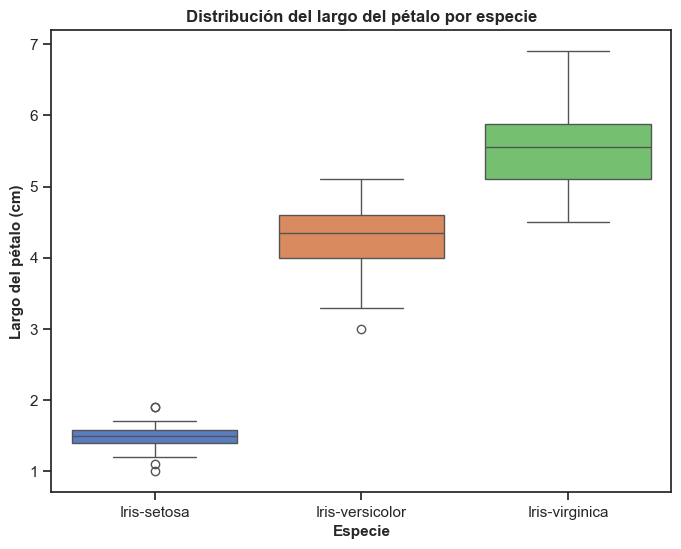

In [3]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='species', y='petal_length_cm', data=data_iris, palette='muted')
plt.xlabel('Especie', fontweight='bold', fontsize=11)
plt.ylabel('Largo del pétalo (cm)', fontweight='bold', fontsize=11)
plt.title('Distribución del largo del pétalo por especie', fontweight='bold')
plt.show()

**Observación:** La especie *virginica* presenta la mayor mediana del largo del pétalo, seguida de *versicolor* y finalmente *setosa*, que muestra valores notablemente más bajos y poca dispersión.

## Ítem 3 — Boxplot con media superpuesta

> **Añada al gráfico anterior una representación de la media del largo del pétalo para cada especie. Para ello, puede utilizar `pointplot()` o una capa adicional con `stripplot()`/`scatterplot()` a partir de datos agregados.**
>
> **Sugerencia:** para construir estos datos agregados, calcule previamente la media del largo del pétalo para cada especie, obteniendo un *DataFrame* reducido con una fila por especie.
>
> Una vez que tenga el gráfico construido, compare media y mediana en cada especie. ¿Qué indica esto sobre la simetría de las distribuciones?

C:\Users\PC\AppData\Local\Temp\ipykernel_15832\2165610741.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species', y='petal_length_cm', data=data_iris, palette='muted', ax=ax)


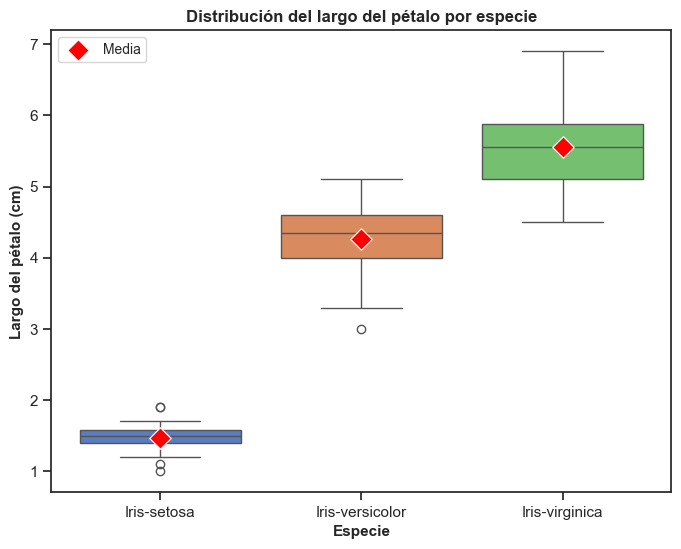

In [4]:
medias_iris = data_iris.groupby('species')['petal_length_cm'].mean().reset_index()

fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(x='species', y='petal_length_cm', data=data_iris, palette='muted', ax=ax)
sns.scatterplot(x='species', y='petal_length_cm', data=medias_iris,
                color='red', marker='D', s=120, zorder=5, ax=ax, label='Media')
ax.set_xlabel('Especie', fontweight='bold', fontsize=11)
ax.set_ylabel('Largo del pétalo (cm)', fontweight='bold', fontsize=11)
ax.set_title('Distribución del largo del pétalo por especie', fontweight='bold')
ax.legend(fontsize=10)
plt.show()

**Observación:** En *setosa* y *virginica* la media y la mediana son muy similares, lo que sugiere distribuciones aproximadamente simétricas. En *versicolor* la media es ligeramente superior a la mediana, indicando un leve sesgo a la derecha.

## Ítem 4 — Gráficos de violín en paneles (ancho de sépalo y pétalo)

> **Reproduzca el gráfico en paneles mostrado en la figura, en el que se presentan gráficos de violín para el ancho de sépalo (`sepal_width_cm`) y ancho de pétalo (`petal_width_cm`). Utilice `plt.subplots()` para crear los paneles y personalice cada gráfico en su respectivo eje. Superponga además los datos individuales mediante `stripplot()`.**
>
> **Sugerencias:**
> - Utilice **lightblue** y **darkorange** como colores para el relleno de los gráficos de violín.
> - Elimine los valores del eje vertical para mejorar la presentación.
> - Ajuste el parámetro `jitter` en `stripplot()` para evitar la superposición excesiva de puntos.
>
> Analice los gráficos obtenidos. ¿Cuál de las siguientes opciones describe de una **manera más precisa** la forma de cada una de las distribuciones?
> *Distribución simétrica / sesgada a la derecha / unimodal / bimodal / normal / sesgada a la izquierda / uniforme*

C:\Users\PC\AppData\Local\Temp\ipykernel_15832\2805342358.py:6: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(x='sepal_width_cm', color='black', alpha=0.6, data=data_iris,
C:\Users\PC\AppData\Local\Temp\ipykernel_15832\2805342358.py:14: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(x='petal_width_cm', color='black', alpha=0.6, data=data_iris,


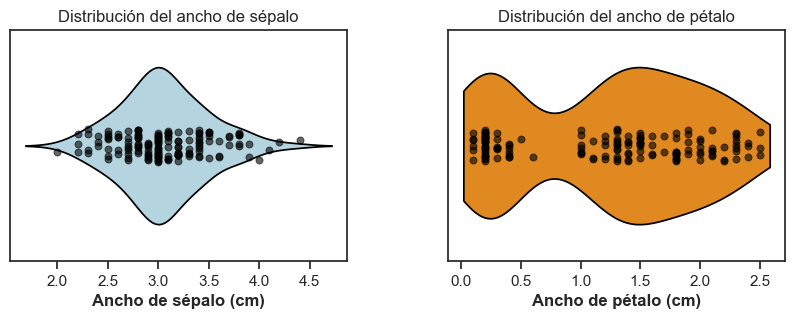

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
plt.subplots_adjust(hspace=0.5, wspace=0.3)

sns.violinplot(x='sepal_width_cm', color='lightblue', fill=True, data=data_iris,
               ax=axes[0], inner=None, linecolor='black', gap=0.15)
sns.stripplot(x='sepal_width_cm', color='black', alpha=0.6, data=data_iris,
              ax=axes[0], jitter=0.07, linewidth=0.7, edgecolor='gray')
axes[0].set_xlabel('Ancho de sépalo (cm)', fontweight='bold')
axes[0].set_yticks([])
axes[0].set_title('Distribución del ancho de sépalo')

sns.violinplot(x='petal_width_cm', color='darkorange', fill=True, data=data_iris,
               ax=axes[1], cut=0.3, inner=None, linecolor='black', gap=0.15)
sns.stripplot(x='petal_width_cm', color='black', alpha=0.6, data=data_iris,
              ax=axes[1], jitter=0.07, linewidth=0.7, edgecolor='gray')
axes[1].set_xlabel('Ancho de pétalo (cm)', fontweight='bold')
axes[1].set_title('Distribución del ancho de pétalo')
axes[1].set_yticks([])

plt.show()

**Análisis:**
- **Ancho de sépalo:** la distribución es aproximadamente *unimodal* y *simétrica* (forma similar a una campana).
- **Ancho de pétalo:** la distribución es claramente *bimodal*, con dos grupos bien diferenciados (uno concentrado cerca de 0.2 cm y otro entre 1.0 y 2.0 cm), lo que refleja la separación entre *setosa* y las otras dos especies.

## Ítem 5 — Relación entre ancho y largo del pétalo

> **Construya un gráfico que le permita analizar la relación general que existe entre las variables ancho y largo del pétalo. Realice un comentario acerca de lo observado y complemente el gráfico anterior informando una medida de la fuerza y la dirección de la asociación lineal entre ambas variables.**

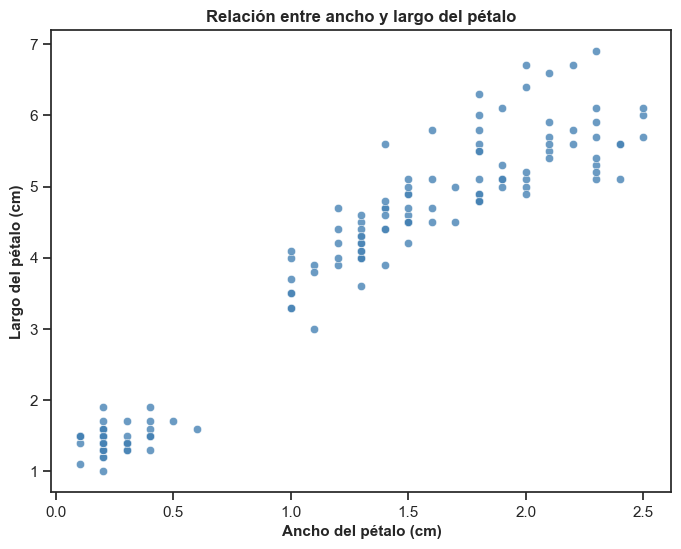

Correlación de Pearson (r): 0.963


In [6]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='petal_width_cm', y='petal_length_cm', data=data_iris,
                color='steelblue', edgecolor='white', alpha=0.8)
plt.xlabel('Ancho del pétalo (cm)', fontweight='bold', fontsize=11)
plt.ylabel('Largo del pétalo (cm)', fontweight='bold', fontsize=11)
plt.title('Relación entre ancho y largo del pétalo', fontweight='bold')
plt.show()

r = data_iris[['petal_width_cm', 'petal_length_cm']].corr().loc['petal_width_cm', 'petal_length_cm']
print(f'Correlación de Pearson (r): {r:.3f}')

**Observación:** Existe una asociación lineal positiva muy fuerte entre el ancho y el largo del pétalo (r ≈ 0.96). A mayor ancho de pétalo, mayor es también su largo.